# Spectral ranges for phytoplasma detection in apple trees — Barthel et al. 2023 reproduction

**Paper:** *"Identification of spectral ranges that contribute to phytoplasma detection in apple
trees — A step towards an on-site method."* Spectrochimica Acta Part A: Molecular and Biomolecular
Spectroscopy 303 (2023) 123246. DOI: [10.1016/j.saa.2023.123246](https://doi.org/10.1016/j.saa.2023.123246)

**Author code:** Dana Barthel (Eurac Research), https://github.com/HyperspectralCameron/Barthel_2023
pinned at commit `177b524fe7fe3189463a54aa2ebe8467465a5267`.

**Scope (partial demonstration):** re-run the paper's spectral-classification subsection on all
seven 2021 field campaigns — leaf-reflectance transformation (log(1/R) + Savitzky–Golay first
derivative), per-campaign PCA (Figure 3), PLS-DA with leave-one-out cross-validation on infection
status, per-month accuracy, VIP-selected discriminating wavelengths (Figure 4), and group
comparison at the representative wavelengths (Figure 5). The authors' own R code is executed via
`Rscript`; the Python cells only orchestrate, download data, and display figures.

**AI-assisted orchestration statement:** The R analysis follows the authors' pinned R script
verbatim where possible. The Python/Colab orchestration, figure assembly, and two script-bug
fixes are AI-generated; the authors did not provide this Colab implementation. The executed
example and listed checks were validated, but untested behavior is not guaranteed.
Fixed/documented deviations: (1) `Rep.Wavelengths$Nov` → `$November` (typo); (2) the
`ggpubr::get_legend(...'513.2 nm')` reference to a nonexistent element is replaced by base-R
panels; (3) the April/October placeholder difference curves (author code mixed `trans_df7`
with other months' infection indices) are computed from each month's own data; (4) `verboseIter=FALSE`
(output only); (5) the author's `tuneLength` uses the April tree count for all months — kept verbatim;
(6) the authors' `bands` x-axis vector was sliced from the outlier-reduced `list_df2$bands`
(994 elements), shifting plot x-labels by two wavelength-grid positions (~3 nm) relative to the
actual spectral columns; this notebook derives the grid from the real `savitzkyGolay` column
names (identical for all campaigns, asserted).

**AI支援に関する注記:** 本notebookは著者らのR解析（固定コミット）を`Rscript`でそのまま再実行します。
Pythonオーケストレーション・図の組版・2件のスクリプトバグ修正はAIが生成しました。実行済みの
最小例と記載の検証は確認済みですが、未検証の挙動は保証されません。

## Runtime selection — CPU only
**Select Runtime → Change runtime type → CPU** (any standard CPU runtime). This method is
small-matrix statistics (PLS-DA / PCA on ~12–23 trees × 835 wavelengths); no GPU is used anywhere
in the paper's method, no trained weights are needed (PLS models are fit from data in-script),
and a T4 would add nothing. **Run all** end-to-end takes only a few minutes: package install
<1 min (prebuilt binaries), 3.4 MB data download, LOOCV ≈ 10 s (measured on 2026-10-09,
Colab CPU, R 4.6.1).

**実行環境の選択:** CPUのみで十分です（GPU不要）。すべて実行しても数分です。

**Environment setup.** Checks for `Rscript` (Colab CPU images ship R), then installs the five
required R packages — `prospectr` (Savitzky–Golay), `caret` + `pls` (PLS-DA LOOCV), `dplyr`
(tables), `multcomp` (Tukey) — preferring prebuilt `r-cran-*` apt binaries and falling back to
CRAN source installation for anything apt lacks. Prints the resulting R and package versions.
必要なRパッケージを導入し、バージョンを表示します。

In [ ]:
import shutil, subprocess, time

def sh(cmd, timeout=3600):
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True, timeout=timeout)
    out = (p.stdout + p.stderr)
    print("$ " + cmd + "\n[exit %d] " % p.returncode + (out[-1500:] if len(out) > 1500 else out))
    return p.returncode

if not shutil.which("Rscript"):
    sh("DEBIAN_FRONTEND=noninteractive apt-get update -qq", timeout=900)
    sh("DEBIAN_FRONTEND=noninteractive apt-get install -y -qq r-base", timeout=3600)

NEEDED = ["prospectr", "caret", "dplyr", "multcomp", "pls"]
def missing():
    expr = ('cat(paste(setdiff(c(%s), rownames(installed.packages())), collapse=" "))'
            % ",".join('"%s"' % p for p in NEEDED))
    return subprocess.run(["Rscript", "-e", expr], capture_output=True, text=True).stdout.strip()

t0 = time.time()
if missing():
    sh("DEBIAN_FRONTEND=noninteractive apt-get update -qq", timeout=900)
    apt = " ".join("r-cran-" + p for p in missing().split())
    sh("DEBIAN_FRONTEND=noninteractive apt-get install -y -qq " + apt, timeout=3600)
if missing():
    expr = ('install.packages(c(%s), repos="https://cloud.r-project.org", Ncpus=2)'
            % ",".join('"%s"' % p for p in missing().split()))
    p = subprocess.run(["Rscript", "-e", expr], capture_output=True, text=True, timeout=7200)
    print("CRAN fallback exit", p.returncode, (p.stdout + p.stderr)[-1500:])
print("setup wall seconds: %d" % (time.time() - t0))
ver = ('cat(R.version.string, "\\n"); for (p in c(%s)) cat(p, as.character(packageVersion(p)), "\\n")'
       % ",".join('"%s"' % p for p in NEEDED))
print(subprocess.run(["Rscript", "-e", ver], capture_output=True, text=True).stdout)

setup wall seconds: 0


R version 4.6.1 (2026-06-24) 
prospectr 0.2.11 
caret 7.0.1 
dplyr 1.2.1 
multcomp 1.4.32 
pls 2.9.0 



**Data acquisition (inside Colab only).** Downloads the two author-supplied RData files from
the pinned commit `177b524fe7fe3189463a54aa2ebe8467465a5267` of
`HyperspectralCameron/Barthel_2023` and verifies them against the GitHub tree metadata:
`Spectroradiometer.RData` (3,424,452 bytes; seven monthly campaigns of raw leaf reflectance,
tree IDs, PCR-based infection labels, symptom groups, and the wavelength grid) and
`important_wavelength.RData` (1,191 bytes; the authors' saved VIP>1 wavelength vectors used for
cross-checking). Verification rejects Git-LFS pointers or HTML error bodies and checks the git
blob SHA-1 (`sha1("blob <size>\\0" + bytes)`).
データ2件をColab内でダウンロードし、サイズとblob SHA-1を検証します。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "177b524fe7fe3189463a54aa2ebe8467465a5267"
EXPECTED = {  # name: (size bytes, git blob sha1 from the GitHub tree API)
    "Spectroradiometer.RData": (3424452, "8da59b0e935d05f6b18fcf493593cb92a56cf1dd"),
    "important_wavelength.RData": (1191, "40a11d9c7ddf31c9a0c0dfa84aee91f0c820c398"),
}
DATA_DIR = pathlib.Path("/content/barthel2023"); DATA_DIR.mkdir(parents=True, exist_ok=True)
for name, (size, blob) in EXPECTED.items():
    url = "https://raw.githubusercontent.com/HyperspectralCameron/Barthel_2023/%s/%s" % (COMMIT, name)
    raw = urllib.request.urlopen(urllib.request.Request(url), timeout=120).read()
    assert len(raw) == size, (name, "unexpected size", len(raw))
    assert not raw.lstrip().startswith(b"version https://git-lfs"), name + " is an LFS pointer"
    assert not raw.lstrip().startswith(b"404"), name + " is an error body"
    digest = hashlib.sha1(b"blob %d\x00" % len(raw) + raw).hexdigest()
    assert digest == blob, (name, digest, blob)
    (DATA_DIR / name).write_bytes(raw)
    print("%s: %d bytes, blob sha1 verified" % (name, len(raw)))
(DATA_DIR / "figs").mkdir(exist_ok=True)

Spectroradiometer.RData: 3424452 bytes, blob sha1 verified
important_wavelength.RData: 1191 bytes, blob sha1 verified


**Load and preprocess (authors' operations, verbatim).** This R step follows
`7_article_submission.Rmd` lines 40–92 exactly: load both RData files, remove the two May
outlier trees (`3_103`, `3_71` at positions 9 and 17 — asserted before removal), compute
absorbance `log(1/R)`, apply `prospectr::savitzkyGolay(m=1, p=2, w=9)`, restrict to the 835
modelling bands, and rebuild the per-campaign `datasets.by.month`
with the authors' exact element drops (positions asserted to be `value`). One documented fix:
the modelling wavelength grid is taken from the real `savitzkyGolay` column names (the authors
sliced their `bands` vector from the outlier-reduced May list, which shifts labels by two grid
positions). Prints per-campaign tree counts, band grid, and infection/group tables, and saves
the preprocessed state to `stage1.RData` for the following cells (each cell runs its own
`Rscript` process). RDataの内部構造はここで初めて検証されます。

In [ ]:
import subprocess, textwrap

r_pre = textwrap.dedent(r"""
    suppressPackageStartupMessages(library(prospectr))
    setwd("/content/barthel2023")
    load("Spectroradiometer.RData")    # list_df1..7, df, list_col, pcr
    load("important_wavelength.RData") # author-saved important_* wavelength vectors
    cat("objects after load:", paste(ls(), collapse=" "), "\n")
    stopifnot(which(list_df2$tree == "3_103") == 9, which(list_df2$tree == "3_71") == 17)
    ol <- c(9, 17)  # author's May outlier trees 3_103, 3_71
    list_df2 <- list(tree=list_df2$tree[-ol], Infection=list_df2$Infection[-ol],
                     Latent=list_df2$Latent[-ol], bands=list_df2$bands[-ol],
                     value=list_df2$value[-ol, ], group=list_df2$group[-ol])
    dfs <- list(list_df1, list_df2, list_df3, list_df4, list_df5, list_df6, list_df7)
    trans_all <- lapply(dfs, function(m) savitzkyGolay(log(1/m$value), m=1, p=2, w=9))
    trans_all <- lapply(trans_all, function(t) t[, 88:922])  # 835 modelling bands
    stopifnot(isTRUE(all.equal(list_df1$bands, list_df3$bands)),
              isTRUE(all.equal(list_df1$bands, list_df7$bands)))  # grid identical across campaigns
    bands <- as.numeric(sub("^X", "", colnames(trans_all[[1]])))  # true grid from SG colnames
    stopifnot(length(bands) == 835, all(abs(bands - list_df1$bands[5:992][88:922]) < 0.05))
    stopifnot(all(abs(as.numeric(sub("^X", "", colnames(trans_all[[2]]))) - bands) < 0.05))
    stopifnot(names(list_df1)[7] == "value", names(list_df2)[5] == "value",
              names(list_df3)[7] == "value", names(list_df4)[8] == "value",
              names(list_df5)[8] == "value", names(list_df6)[8] == "value",
              names(list_df7)[7] == "value")
    datasets.by.month <- list(
      "April"    = c(list_df1[-7], list("value" = as.data.frame(trans_all[[1]]))),
      "May"      = c(list_df2[-5], list("value" = as.data.frame(trans_all[[2]]))),
      "June"     = c(list_df3[-7], list("value" = as.data.frame(trans_all[[3]]))),
      "July"     = c(list_df4[-8], list("value" = as.data.frame(trans_all[[4]]))),
      "August"   = c(list_df5[-8], list("value" = as.data.frame(trans_all[[5]]))),
      "October"  = c(list_df6[-8], list("value" = as.data.frame(trans_all[[6]]))),
      "November" = c(list_df7[-7], list("value" = as.data.frame(trans_all[[7]]))))
    cat("modelling bands:", length(bands), " covering ", format(range(bands)), " nm\n")
    cat("author-saved importance objects:",
        paste(intersect(c("important_Apr","important_Oct","important_Nov","important_End"), ls()),
              collapse=", "), "\n")
    for (nm in names(datasets.by.month)) {
      d <- datasets.by.month[[nm]]
      cat(sprintf("%-8s trees=%2d bands=%3d infected yes/no=%2d/%2d groups=%s\n", nm,
          nrow(d$value), ncol(d$value), sum(d$Infection == "yes"),
          sum(d$Infection == "no"), paste(levels(as.factor(d$group)), collapse=",")))
    }
    MONTHS <- names(datasets.by.month)
    Rep_WL <- list(April = 691.5, October = c(500.4, 682.2, 1878.1), November = 507.5)  # script L330-334
    save(datasets.by.month, bands, MONTHS, Rep_WL,
         important_Apr, important_Oct, important_Nov, important_End, file = "stage1.RData")
    cat("saved stage1.RData (state passed to the following cells)\n")
""")
pathlib.Path("/content/barthel2023/preprocess.R").write_text(r_pre)
p = subprocess.run(["Rscript", "/content/barthel2023/preprocess.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("preprocess.R failed")

objects after load: df important_Apr important_End important_Nov important_Oct list_col list_df1 list_df2 list_df3 list_df4 list_df5 list_df6 list_df7 pcr 
modelling bands: 835  covering   471.9 2355.3  nm
author-saved importance objects: important_Apr, important_Oct, important_Nov, important_End 
April    trees=12 bands=835 infected yes/no= 8/ 4 groups=A,B,C,NON
May      trees=21 bands=835 infected yes/no=12/ 9 groups=A,B,C,NON
June     trees=23 bands=835 infected yes/no=14/ 9 groups=A,B,C,NON
July     trees=23 bands=835 infected yes/no=14/ 9 groups=A,B,C,NON
August   trees=23 bands=835 infected yes/no=14/ 9 groups=A,B,C,NON
October  trees=23 bands=835 infected yes/no=14/ 9 groups=A,B,C,NON
November trees=23 bands=835 infected yes/no=14/ 9 groups=A,B,C,NON
saved stage1.RData (state passed to the following cells)



**Input preview — measured spectra by infection class.** Reproduces the authors' Figure A1
transformation overview from the actual downloaded data: raw reflectance, absorbance
`log(1/R)`, and first-derivative absorbance for every measured tree, pooled across all seven
campaigns, colored by PCR-confirmed infection status (blue = non-infected, red = APP infected).
This previews the real inputs before any modelling; it is an input-level view, not a result.
実データのスペクトル（原反射・吸光度・1次微分）を感染状態で色分けして確認します。

null device 
          1 
wrote figs/input_spectra.png rows: 150 



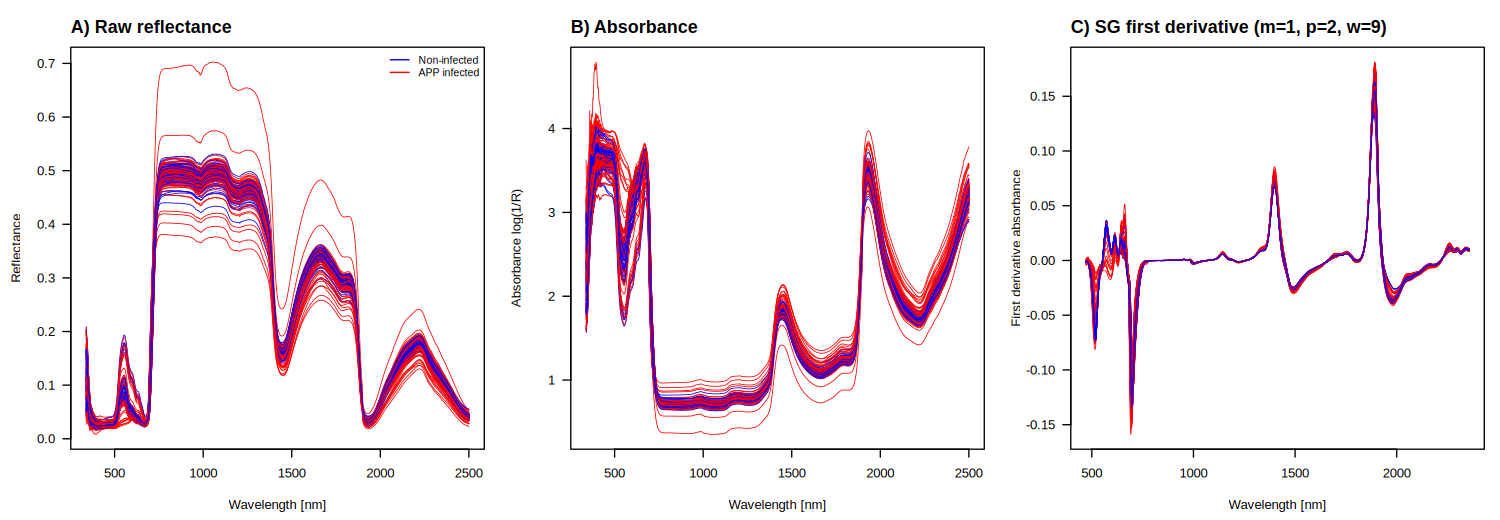

In [ ]:
import subprocess, textwrap

r_fig = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("Spectroradiometer.RData")  # raw reflectance for the input preview
    load("stage1.RData")             # bands (modelling grid) from the preprocessing cell
    suppressPackageStartupMessages(library(prospectr))
    dfs <- list(list_df1, list_df2, list_df3, list_df4, list_df5, list_df6, list_df7)
    infection <- unlist(lapply(dfs, function(m) m$Infection))
    cols <- c("blue", "red")[as.integer(as.factor(infection))]
    raw <- do.call(rbind, lapply(dfs, function(m) m$value))
    ab  <- do.call(rbind, lapply(dfs, function(m) log(1/m$value)))
    tr  <- do.call(rbind, lapply(dfs, function(m)
           savitzkyGolay(log(1/m$value), m=1, p=2, w=9)[, 88:922]))
    png("figs/input_spectra.png", width=1500, height=520, res=130, pointsize=11)
    par(mfrow=c(1, 3), mar=c(4.5, 4.5, 3, 1))
    matplot(x=list_df1$bands, y=t(raw), type="l", lty=1, lwd=0.6, col=cols, las=1,
            xlab="Wavelength [nm]", ylab="Reflectance")
    legend("topright", c("Non-infected", "APP infected"), col=c("blue", "red"), lty=1, bty="n", cex=0.8)
    mtext("A) Raw reflectance", side=3, line=0.7, at=par('usr')[1], adj=0, cex=0.9, font=2)
    matplot(x=list_df1$bands, y=t(ab), type="l", lty=1, lwd=0.6, col=cols, las=1,
            xlab="Wavelength [nm]", ylab="Absorbance log(1/R)")
    mtext("B) Absorbance", side=3, line=0.7, at=par('usr')[1], adj=0, cex=0.9, font=2)
    matplot(x=bands, y=t(tr), type="l", lty=1, lwd=0.6, col=cols, las=1,
            xlab="Wavelength [nm]", ylab="First derivative absorbance")
    mtext("C) SG first derivative (m=1, p=2, w=9)", side=3, line=0.7, at=par('usr')[1], adj=0, cex=0.9, font=2)
    dev.off()
    cat("wrote figs/input_spectra.png rows:", nrow(raw), "\n")
""")
pathlib.Path("/content/barthel2023/fig_input.R").write_text(r_fig)
p = subprocess.run(["Rscript", "/content/barthel2023/fig_input.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("fig_input.R failed")
from IPython.display import Image, display
display(Image(filename="/content/barthel2023/figs/input_spectra.png"))

**Per-campaign PCA score plots (authors' Figure 3).** Runs an unsupervised `prcomp`
(scale=FALSE) per campaign on the transformed spectra and plots PC1 vs PC2 for all seven
sampling dates — point shape encodes PCR infection status (circle = non-infected, triangle =
APP infected) and color encodes the symptom/colonization group (red→blue gradient for
A/B/C/NON). This is the authors' own exploratory figure; class separation is expected to be
strongest in the campaigns the paper highlights (April, October, November).
各キャンペーンのPCAスコアプロット（著者のFigure 3に対応）。

null device 
          1 
wrote figs/fig3_pca.png



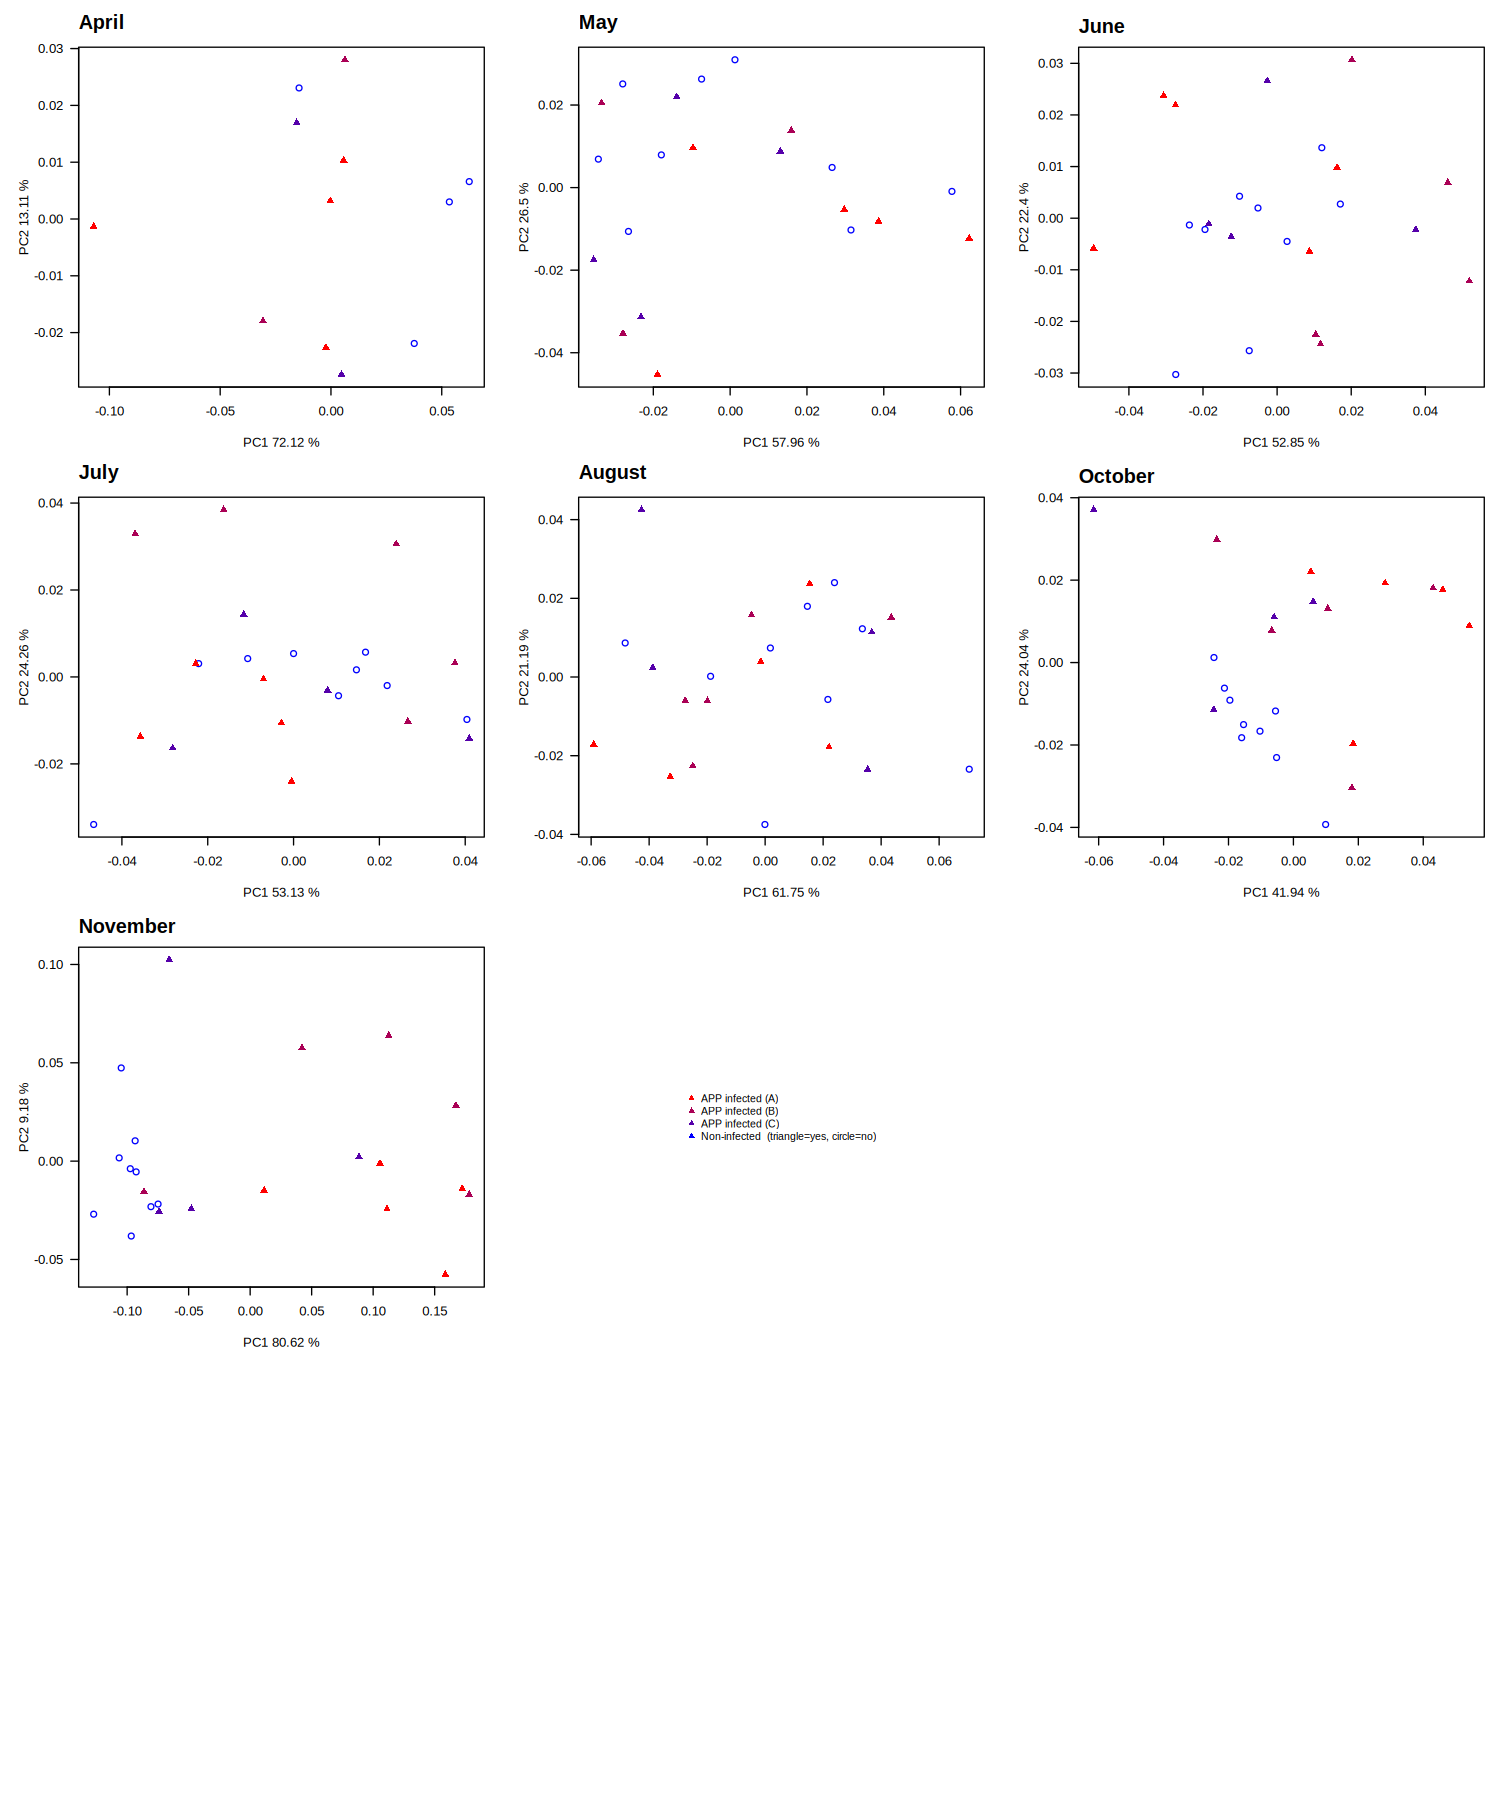

In [ ]:
import subprocess, textwrap

r_pca = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("stage1.RData")  # datasets.by.month, bands, MONTHS
    colfunc <- colorRampPalette(c("red", "blue")); color <- colfunc(4)
    png("figs/fig3_pca.png", width=1500, height=1800, res=130, pointsize=11)
    par(mfrow=c(4, 3), mar=c(4, 5, 3, 1))
    for (nm in MONTHS) {
      d <- datasets.by.month[[nm]]
      pca <- prcomp(as.matrix(d$value), scale.=FALSE)
      imp <- summary(pca)$importance
      pc1 <- round(imp[2, 1] * 100, 2); pc2 <- round(imp[2, 2] * 100, 2)
      plot(pca$x[, 1:2], pch=c(1, 17)[as.integer(as.factor(d$Infection))],
           col=color[as.integer(as.factor(d$group))], las=1,
           xlab=paste0("PC1 ", pc1, " %"), ylab=paste0("PC2 ", pc2, " %"))
      mtext(bquote(bold(.(nm))), side=3, line=0.7, at=par('usr')[1], cex=1, adj=0)
    }
    plot.new(); legend("center", legend=c("APP infected (A)","APP infected (B)",
      "APP infected (C)","Non-infected  (triangle=yes, circle=no)"),
      col=color, pch=17, bty="n", cex=0.8, xpd=NA)
    dev.off()
    cat("wrote figs/fig3_pca.png\n")
""")
pathlib.Path("/content/barthel2023/fig_pca.R").write_text(r_pca)
p = subprocess.run(["Rscript", "/content/barthel2023/fig_pca.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("fig_pca.R failed")
from IPython.display import Image, display
display(Image(filename="/content/barthel2023/figs/fig3_pca.png"))

**PLS-DA with leave-one-out cross-validation (authors' classification subsection).** For each
monthly campaign, trains `caret::train(method="pls")` with `Infection` as the class label,
LOOCV resampling, and `tuneLength = length(April tree) - 2` — the authors' exact call (this
April-derived value is kept verbatim; it is valid for every campaign since all have 12–23
trees). `verboseIter` is turned off for readable output only. Wall time is printed; on the
2026-10-09 CPU probe all seven LOOCV runs took ≈ 7 s total. 系統ごとのPLS-DA
（LOOCV）を著者の呼び出しのまま実行します。

In [ ]:
import subprocess, textwrap

r_pls = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("stage1.RData")  # datasets.by.month, MONTHS
    suppressPackageStartupMessages({library(caret); library(dplyr)})
    tune_len <- length(datasets.by.month$April$tree) - 2  # author's verbatim tuneLength
    cat("tuneLength:", tune_len, "\n")
    t0 <- Sys.time()
    trained.models <- lapply(datasets.by.month, function(dataset) {
      train(x = dataset$value, y = dataset$Infection, method = "pls",
            trControl = trainControl(method = "LOOCV", verboseIter = FALSE),
            tuneLength = tune_len)
    })
    elapsed <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
    cat(sprintf("total LOOCV wall seconds: %.1f\n", elapsed))
    get_elements <- function(x, element) {  # authors' helper, verbatim
      if (is.list(x)) { if (element %in% names(x)) x[[element]]
                        else lapply(x, get_elements, element = element) }
    }
    results <- get_elements(trained.models, "results") %>% bind_rows(.id = "id") %>%
      group_by(id) %>% slice_max(Accuracy) %>% slice_min(ncomp)
    results$id <- factor(results$id, levels = MONTHS, ordered = TRUE)
    results <- results %>% arrange(id) %>% rename(Month = id, `Latent Variables` = ncomp)
    print(as.data.frame(results[, c("Month", "Latent Variables", "Accuracy")]), digits = 3)
    write.csv(as.data.frame(results), "results_plsda_loocv.csv", row.names = FALSE)
    cat("wrote results_plsda_loocv.csv\n")
    save(trained.models, results, file = "stage2.RData")
    cat("saved stage2.RData\n")
""")
pathlib.Path("/content/barthel2023/plsda.R").write_text(r_pls)
p = subprocess.run(["Rscript", "/content/barthel2023/plsda.R"],
                   capture_output=True, text=True, timeout=3600)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("plsda.R failed")

tuneLength: 10 
total LOOCV wall seconds: 14.5
     Month Latent Variables Accuracy
1    April                1    0.917
2      May                6    0.667
3     June                6    0.609
4     July                5    0.696
5   August                3    0.652
6  October                2    0.870
7 November                5    0.870
wrote results_plsda_loocv.csv
saved stage2.RData



**Variable importance and cross-check against the authors' saved results.** Computes
`varImp(scale=FALSE)` per campaign, extracts the VIP Overall score > 1 wavelengths for April,
October, and November (the campaigns where classification works), and compares them with the
`important_Apr/important_Oct/important_Nov` wavelength vectors the authors saved in
`important_wavelength.RData`. Also verifies the paper's representative wavelengths
(April 691.5 nm; October 500.4, 682.2, 1878.1 nm; November 507.5 nm) are members of the
computed VIP>1 sets and have the highest |correlation| with infection status among them.
VIP>1波長を計算し、著者が保存した重要波長ベクトルと照合します。

In [ ]:
import subprocess, textwrap

r_vip = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("stage1.RData"); load("stage2.RData")  # Rep_WL, important_*, trained.models
    suppressPackageStartupMessages(library(caret))
    Importance <- lapply(trained.models, varImp, scale = FALSE)
    vip <- list()
    for (nm in c("April", "October", "November")) {
      imp <- Importance[[nm]]$importance
      wl <- sort(as.numeric(gsub("^X", "", rownames(imp)[imp$Overall > 1])))
      vip[[nm]] <- wl
      saved_name <- c(April = "important_Apr", October = "important_Oct",
                      November = "important_Nov")[[nm]]
      saved <- sort(get(saved_name))
      cat(sprintf("%-8s computed VIP>1: %3d | author-saved: %3d | common: %3d\n",
                  nm, length(wl), length(saved), length(intersect(wl, saved))))
      m <- datasets.by.month[[nm]]
      y <- as.integer(as.factor(m$Infection))
      cors <- sapply(paste0("X", wl), function(v) abs(cor(y, m$value[[v]])))
      best <- wl[which.max(cors)]
      cat(sprintf("         highest |cor| among VIP>1: %.1f nm | representative per script: %s\n",
                  best, paste(Rep_WL[[nm]], collapse = ",")))
    }
    save(vip, file = "stage3.RData")
    cat("saved stage3.RData\n")
""")
pathlib.Path("/content/barthel2023/vip.R").write_text(r_vip)
p = subprocess.run(["Rscript", "/content/barthel2023/vip.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("vip.R failed")

April    computed VIP>1:   9 | author-saved: 136 | common:   9
         highest |cor| among VIP>1: 691.5 nm | representative per script: 691.5
October  computed VIP>1:  49 | author-saved: 162 | common:  27
         highest |cor| among VIP>1: 500.4 nm | representative per script: 500.4,682.2,1878.1
November computed VIP>1:   5 | author-saved: 228 | common:   5
         highest |cor| among VIP>1: 507.5 nm | representative per script: 507.5
saved stage3.RData



**Discriminating wavelength curves (authors' Figure 4).** For April, October, and November:
(above) the mean first-derivative difference between infected and non-infected trees with all
VIP>1 wavelengths marked orange, and (below) the per-wavelength correlation with infection
status against the ±0.7 threshold. Note the adaptation: the authors' script accidentally drew
the April and October placeholder curves from `trans_df7` with other months' indices; this
notebook computes each month's difference curve from its own data (documented deviation).
VIP波長を感染差分曲線と相関曲線に重ねた図（著者のFigure 4に対応）。

null device 
          1 
wrote figs/fig4_vip.png



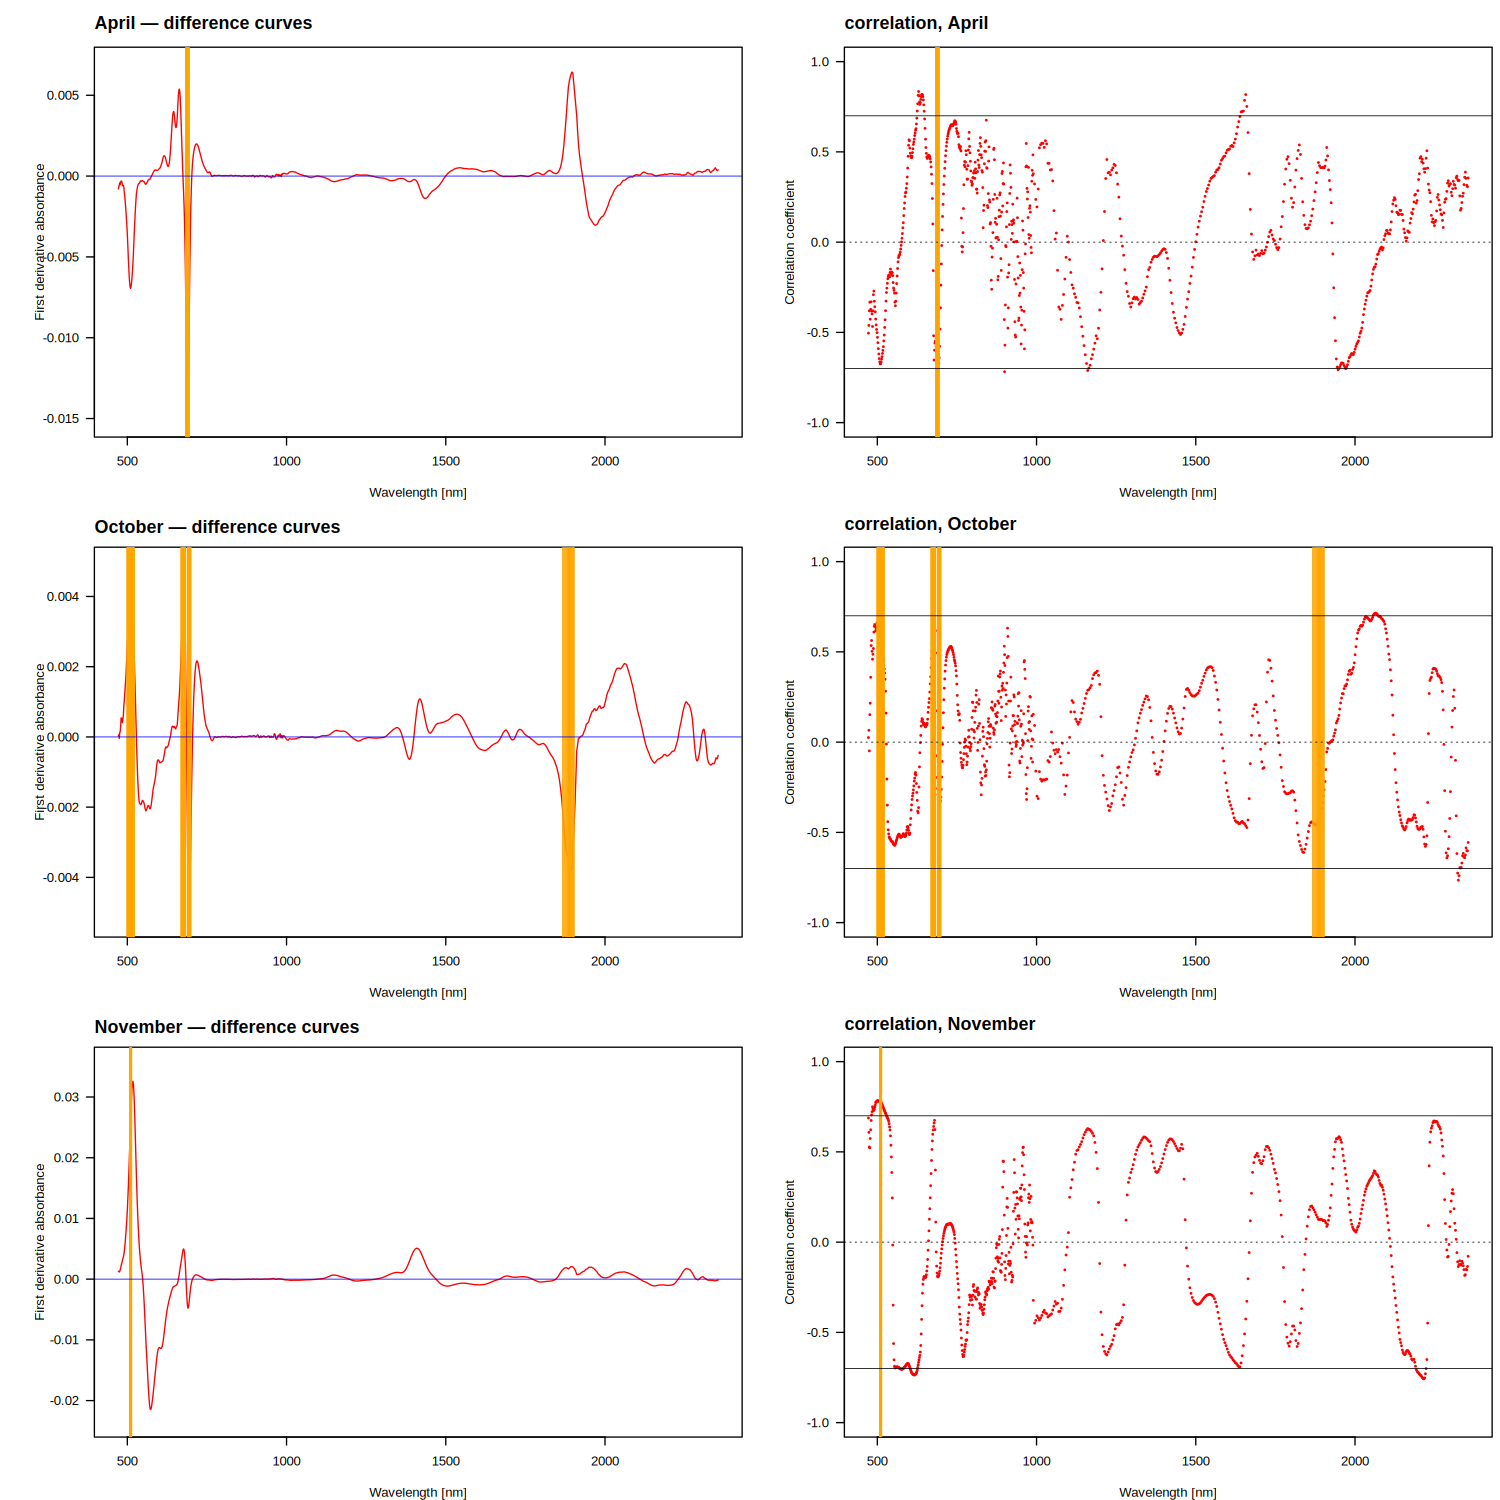

In [ ]:
import subprocess, textwrap

r_fig4 = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("stage1.RData"); load("stage3.RData")  # bands, vip wavelengths
    th <- 0.7
    png("figs/fig4_vip.png", width=1500, height=1500, res=130, pointsize=11)
    par(mfrow=c(3, 2), mar=c(4, 6, 3, 0.5))
    for (nm in c("April", "October", "November")) {
      m <- datasets.by.month[[nm]]; tv <- as.matrix(m$value)
      yes <- m$Infection == "yes"
      diff <- colMeans(tv[yes, , drop = FALSE]) - colMeans(tv[!yes, , drop = FALSE])
      plot(y = diff, x = bands, type = "l", col = "red", las = 1,
           xlab = "Wavelength [nm]", ylab = "First derivative absorbance",
           main = "", ylim = range(diff) * 1.1)
      abline(v = vip[[nm]], lty = 1, col = "orange")
      abline(h = 0, col = "blue", lwd = 0.6)
      mtext(bquote(bold(.(nm) * " — difference curves")), side = 3, line = 0.7,
            at = par('usr')[1], adj = 0, cex = 0.9)
      cr <- as.vector(cor(as.integer(as.factor(m$Infection)), tv))
      plot(y = cr, x = bands, ylim = c(-1, 1), pch = 20, type = "p", col = "red", cex = 0.4,
           xlab = "Wavelength [nm]", ylab = "Correlation coefficient", las = 1, main = "")
      abline(v = vip[[nm]], lty = 1, col = "orange")
      abline(h = c(-th, th), lwd = 0.6); abline(h = 0, lty = 3, lwd = 0.6)
      mtext(bquote(bold("correlation, " * .(nm))), side = 3, line = 0.7,
            at = par('usr')[1], adj = 0, cex = 0.9)
    }
    dev.off()
    cat("wrote figs/fig4_vip.png\n")
""")
pathlib.Path("/content/barthel2023/fig_vip.R").write_text(r_fig4)
p = subprocess.run(["Rscript", "/content/barthel2023/fig_vip.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("fig_vip.R failed")
from IPython.display import Image, display
display(Image(filename="/content/barthel2023/figs/fig4_vip.png"))

**Group comparison at representative wavelengths (authors' Figure 5).** For each
representative wavelength — April 691.5, October 500.4/682.2/1878.1, November 507.5 — extracts
the transformed values, groups them by the symptom/colonization class (`group`: A, B, C, NON),
fits the authors' one-way ANOVA `lm(Measurement ~ Group)` and `multcomp::glht` Tukey HSD, and
draws boxplots annotated with the Tukey `cld` significance letters and the ANOVA p-value. The
authors' `$Nov` typo is fixed to `$November`. 代表波長における群間比較
（ANOVA＋Tukey HSD、著者のFigure 5に対応）。

null device 
          1 
wrote figs/fig5_boxplots.png



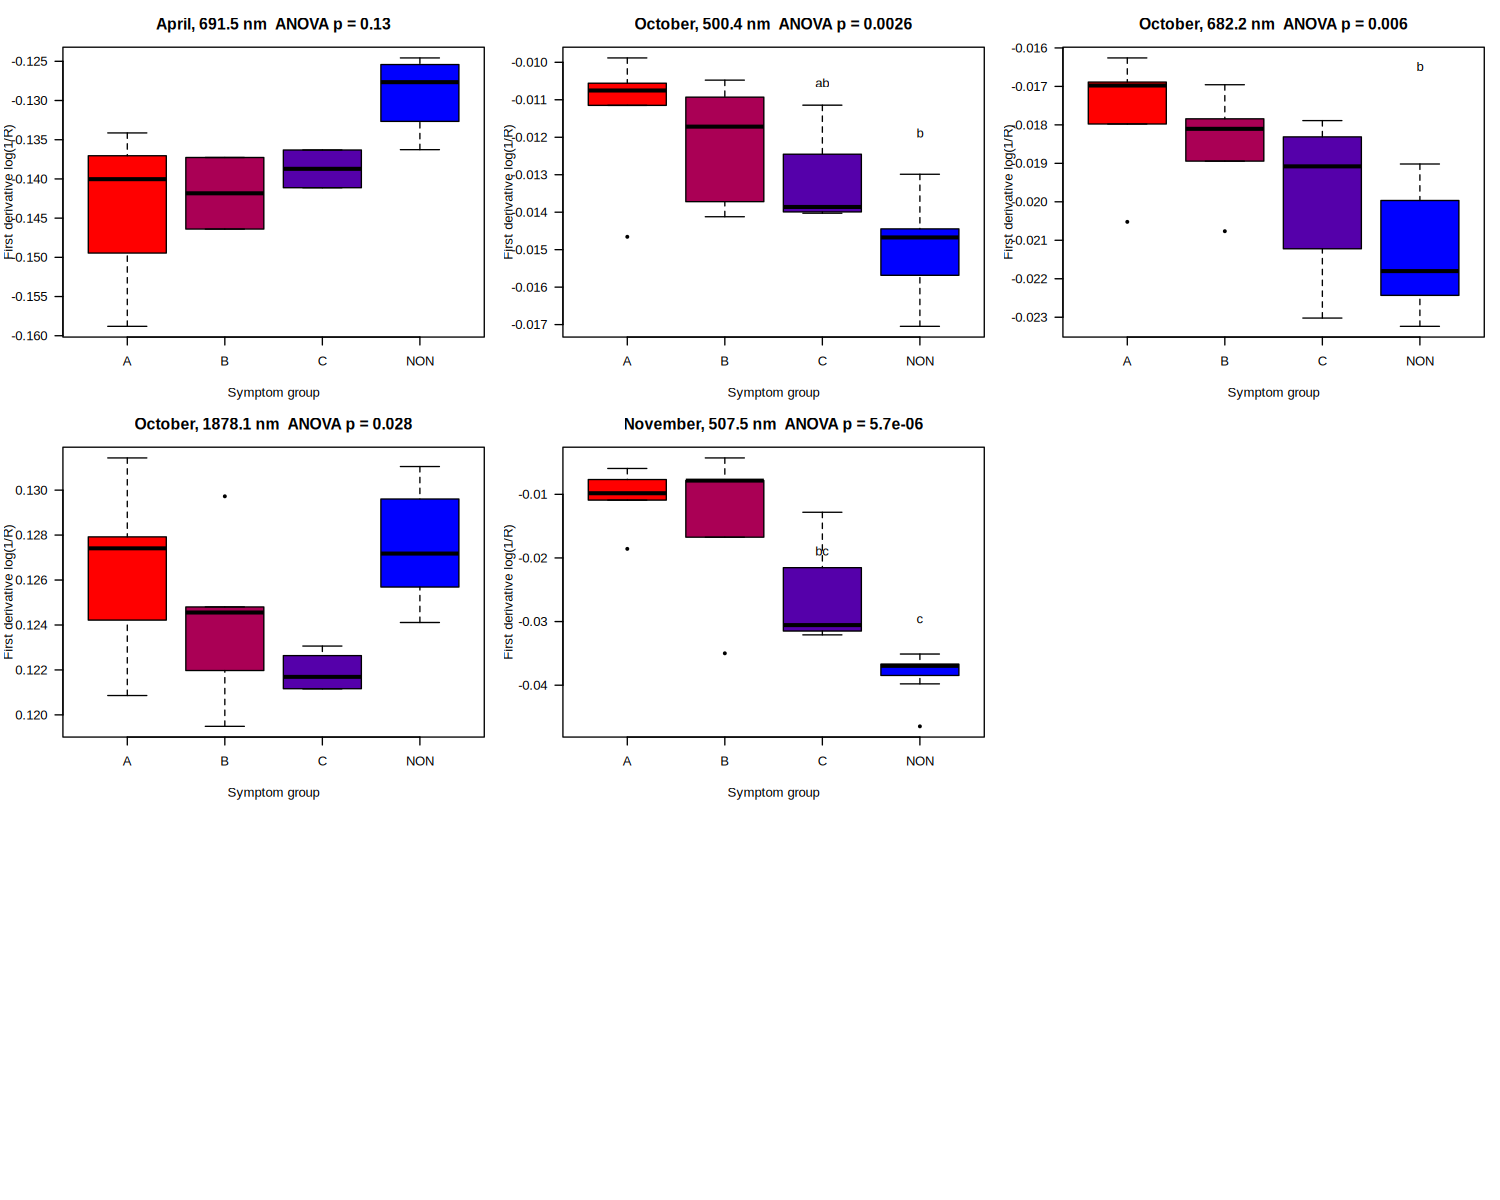

In [ ]:
import subprocess, textwrap

r_fig5 = textwrap.dedent(r"""
    setwd("/content/barthel2023")
    load("stage1.RData")  # datasets.by.month, Rep_WL
    suppressPackageStartupMessages(library(multcomp))
    colfunc <- colorRampPalette(c("red", "blue")); color <- colfunc(4)
    png("figs/fig5_boxplots.png", width=1500, height=1200, res=130, pointsize=11)
    par(mfrow=c(3, 3), mar=c(4, 4, 3, 1))
    for (nm in names(Rep_WL)) {
      m <- datasets.by.month[[nm]]
      for (wl in Rep_WL[[nm]]) {
        variable <- paste0("X", wl)  # exact band names verified in the band grid
        bd <- data.frame(Measurement = as.numeric(m$value[[variable]]),
                         Group = as.factor(m$group))
        fit <- lm(Measurement ~ Group, data = bd)
        pval <- summary(aov(fit))[[1]]$"Pr(>F)"[1]
        letters <- cld(glht(fit, linfct = mcp(Group = "Tukey")))$mcletters$Letters
        uq <- tapply(bd$Measurement, bd$Group, quantile, probs = 0.75)
        boxplot(Measurement ~ Group, data = bd, col = color, las = 1, pch = 20,
                main = sprintf("%s, %g nm  ANOVA p = %.2g", nm, wl, pval),
                xlab = "Symptom group", ylab = "First derivative log(1/R)")
        text(seq_along(levels(bd$Group)), as.numeric(uq) + 0.15 * max(abs(bd$Measurement)),
             labels = letters)
      }
    }
    dev.off()
    cat("wrote figs/fig5_boxplots.png\n")
""")
pathlib.Path("/content/barthel2023/fig_box.R").write_text(r_fig5)
p = subprocess.run(["Rscript", "/content/barthel2023/fig_box.R"],
                   capture_output=True, text=True, timeout=1800)
print(p.stdout)
if p.returncode != 0:
    print(p.stderr); raise RuntimeError("fig_box.R failed")
from IPython.display import Image, display
display(Image(filename="/content/barthel2023/figs/fig5_boxplots.png"))

**Results export.** Loads the per-campaign LOOCV accuracy table back into pandas for a clean
inspectable view and copies the CSV next to the figures. 結果表をCSVとして保存・表示します。

In [ ]:
import pandas as pd, shutil
df = pd.read_csv("/content/barthel2023/results_plsda_loocv.csv")
display(df[["Month", "Latent Variables", "Accuracy"]])
shutil.copy("/content/barthel2023/results_plsda_loocv.csv",
            "/content/barthel2023/figs/results_plsda_loocv.csv")
print("saved figs/results_plsda_loocv.csv")

,Month,Latent Variables,Accuracy
0,April,1,0.916667
1,May,6,0.666667
2,June,6,0.608696
3,July,5,0.695652
4,August,3,0.652174
5,October,2,0.869565
6,November,5,0.869565


saved figs/results_plsda_loocv.csv


## Interpretation and validation record
- **What this run shows:** the executed cells above are this run's actual results — per-campaign
  LOOCV accuracies, VIP>1 wavelength sets (with counts of agreement against the authors' saved
  vectors), difference/correlation curves, and group boxplots at the representative wavelengths.
  They are displayed from the executed data and were **not** edited after execution.
- **Differences from the paper:** only the classification subsection and its figures are
  reproduced (the paper's full results include additional detail and discussion that the article
  full text — unavailable via the attempted routes — would be needed to compare numerically).
  The paper's reported per-month accuracies were **not** compared numerically; this is recorded
  as an unverified gap, not a match claim.
- **One-example caveat:** seven small campaigns (12–23 trees) are the complete published data
  for this subsection, but a successful LOOCV on them does not verify the paper's dataset-level
  claims or an on-site device.
- **Provenance:** author code `7_article_submission.Rmd` @ `177b524` (Dana Barthel, Eurac
  Research); data `Spectroradiometer.RData` (blob `8da59b0e…`) and `important_wavelength.RData`
  (blob `40a11d9c…`) verified by size + git blob SHA-1 on download. R packages: prospectr,
  caret, pls, dplyr, multcomp (versions printed above). No LICENSE file exists in the author
  repository; the code is re-run, not redistributed.

## References
1. Barthel, D. et al. (2023). Identification of spectral ranges that contribute to phytoplasma
   detection in apple trees — A step towards an on-site method. *Spectrochimica Acta Part A*,
   303, 123246. https://doi.org/10.1016/j.saa.2023.123246
2. Barthel, D. — Barthel_2023 repository, commit 177b524.
   https://github.com/HyperspectralCameron/Barthel_2023
3. Stevens, A. & Ramirez-Lopez, L. — *prospectr* (savitzkyGolay); Kuhn, M. — *caret*;
   Hothorn, T., Bretz, F. & Westfall, P. — *multcomp*.

**検証記録（日本語）:** 上記の出力はすべて本実行の実測結果です。論文の報告値との数値比較は
本文全文が取得できなかったため未実施であり、未検証のギャップとして記録しています。
このノートブックは分類サブセクションの部分的再現です。